In [1]:
!pip list

Package                   Version
------------------------- -----------
anyio                     4.14.2
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.2
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
bleach                    6.4.0
certifi                   2026.7.22
cffi                      2.1.0
charset-normalizer        3.4.9
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.21
decorator                 5.3.1
defusedxml                0.7.1
et_xmlfile                2.0.0
executing                 2.2.1
fastjsonschema            2.22.0
fonttools                 4.62.1
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna            

In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:

# Define file path
file_path = "C:\\Users\\CERSAI\\Documents\\E commerce data\\data_ecommerce_customer_churn.xlsx"

# Read all sheets at once (this replaces the sqlite_master query)
excel_file = pd.read_excel(file_path, sheet_name=None)

# Create dataframe for each sheet (replaces your SQL loop)
for sheet_name, df in excel_file.items():
# Cleans sheet names (replaces spaces with underscores for valid variable names)
    clean_name = sheet_name.replace(" ", "_").replace("-", "_")
    
# This creates your dynamic variables (e.g., df_Sheet1) just like your original code did
    globals()[f"df_{clean_name}"] = df
    print(f"Created dataframe: df_{clean_name}")


Created dataframe: df_data_ecommerce_customer_churn


In [4]:
# SQLite Database connect / create karo
conn = sqlite3.connect('ecommerce_churn.db')

# Excel se aaye DataFrame ko SQL table me conversion
df.to_sql('churn_table', conn, if_exists='replace', index=False)

print("SQL Table 'churn_table' successfully create ho gayi!")

SQL Table 'churn_table' successfully create ho gayi!


In [5]:
# First test SQL query
query = "SELECT * FROM churn_table LIMIT 5;"
pd.read_sql_query(query, conn)

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [6]:
#data cleaning
df = df_data_ecommerce_customer_churn
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   str    
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   str    
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 338.8 KB


In [8]:
# Exact count of missing values per column
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# dataframe summary
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Percentage (%)': missing_percent})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Percentage (%)
Tenure,194,4.922608
WarehouseToHome,169,4.288252
DaySinceLastOrder,213,5.404720


In [9]:
# Modern Pandas syntax (without warning)
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())
df['WarehouseToHome'] = df['WarehouseToHome'].fillna(df['WarehouseToHome'].median())
df['DaySinceLastOrder'] = df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].median())

# Re-check missing values
print("Now Total missing values :", df.isnull().sum().sum())

Now Total missing values : 0


In [10]:
# check duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate rows count:", duplicates)

# to remove the duplicates
df.drop_duplicates(inplace=True)

Duplicate rows count: 672


In [11]:
# update dataframe after removing duplicates
df = df.drop_duplicates()

# Re-check duplicates
print(f"Duplicates after removal: {df.duplicated().sum()}")

Duplicates after removal: 0


In [12]:
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [13]:
df.tail()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
3933,25.0,15.0,5,Fashion,4,Married,7,0,8.0,249.90,0
3935,26.0,7.0,4,Grocery,1,Married,4,0,9.0,295.99,0
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3940,2.0,7.0,3,Laptop & Accessory,5,Married,1,0,2.0,153.73,0


In [14]:
# Check unique values and count of complaints
print(df['Complain'].value_counts())

Complain
0    2348
1     921
Name: count, dtype: int64


In [15]:
# 1. Tenure Group
def get_tenure_group(tenure):
    if tenure <= 6:
        return '0-6 Months (New)'
    elif tenure <= 24:
        return '6-24 Months (Regular)'
    else:
        return '24+ Months (Loyal)'

df['TenureGroup'] = df['Tenure'].apply(get_tenure_group)

# 2. Distance Category
def get_distance_cat(dist):
    if dist <= 10:
        return 'Near'
    elif dist <= 20:
        return 'Moderate'
    else:
        return 'Far'

df['WarehouseDistanceCat'] = df['WarehouseToHome'].apply(get_distance_cat)

# 3. Recency Status
def get_recency_status(days):
    if days <= 30:
        return 'Active'
    elif days <= 90:
        return 'At Risk'
    else:
        return 'Inactive'

df['RecencyStatus'] = df['DaySinceLastOrder'].apply(get_recency_status)

# Check new columns
df[['Tenure', 'TenureGroup', 'WarehouseToHome', 'WarehouseDistanceCat']].head()

,Tenure,TenureGroup,WarehouseToHome,WarehouseDistanceCat
0,15.0,6-24 Months (Regular),29.0,Far
1,7.0,6-24 Months (Regular),25.0,Far
2,27.0,24+ Months (Loyal),13.0,Moderate
3,20.0,6-24 Months (Regular),25.0,Far
4,30.0,24+ Months (Loyal),15.0,Moderate


In [16]:
df.shape

(3269, 14)

In [17]:
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,TenureGroup,WarehouseDistanceCat,RecencyStatus
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0,6-24 Months (Regular),Far,Active
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0,6-24 Months (Regular),Far,Active
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0,24+ Months (Loyal),Moderate,Active
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0,6-24 Months (Regular),Far,Active
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0,24+ Months (Loyal),Moderate,Active


In [18]:
# to count the unique values in each column
df.nunique()

Tenure                        36
WarehouseToHome               33
NumberOfDeviceRegistered       6
PreferedOrderCat               6
SatisfactionScore              5
MaritalStatus                  3
NumberOfAddress               14
Complain                       2
DaySinceLastOrder             22
CashbackAmount              2335
Churn                          2
TenureGroup                    3
WarehouseDistanceCat           3
RecencyStatus                  2
dtype: int64

In [20]:
df.to_csv("exported_churn_data.csv",index = False)

In [21]:
import os
print("my csv file in this location :")
print(os.getcwd())

my csv file in this location :
C:\Users\CERSAI


In [22]:
#data analysis
#1.churn rate
df.columns

Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn', 'TenureGroup', 'WarehouseDistanceCat', 'RecencyStatus'],
      dtype='str')

In [24]:
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate : {churn_rate :.2f}%")

Overall Churn Rate : 16.34%


In [25]:
# Complain vs Overall Benchmark Query
query_complain = """
SELECT 
    Complain,
    COUNT(*) as Total_Customers,
    SUM(Churn) as Churned_Customers,
    ROUND(AVG(Churn) * 100, 2) as Churn_Rate_Pct
FROM churn_table
GROUP BY Complain;
"""

pd.read_sql_query(query_complain, conn)

,Complain,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,0,2828,309,10.93
1,1,1113,365,32.79


In [26]:
# 2.Retention rate
retention_rate = (1 - df['Churn']).mean() * 100

print(f"Overall Retention Rate: {retention_rate:.2f}%")

Overall Retention Rate: 83.66%


In [27]:
# Category wise Churn Rate and calculate total customers 
category_churn = df.groupby('PreferedOrderCat')['Churn'].agg(
    Total_Customers='count',
    Churned_Customers='sum',
    Churn_Rate_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index()

# sorting churn customers
category_churn = category_churn.sort_values(by='Churn_Rate_Pct', ascending=False)
category_churn

,PreferedOrderCat,Total_Customers,Churned_Customers,Churn_Rate_Pct
3,Mobile,458,124,27.07
4,Mobile Phone,725,195,26.90
0,Fashion,484,75,15.50
2,Laptop & Accessory,1213,119,9.81
5,Others,149,11,7.38
1,Grocery,240,10,4.17


In [29]:
# merging mobile and mobile phone
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

# update sqlite table
df.to_sql('churn_table', conn, if_exists='replace', index=False)

print("successfully merged!")

successfully merged!


In [33]:
category_churn_clean = df.groupby('PreferedOrderCat')['Churn'].agg(
    Total_Customers='count',
    Churned_Customers='sum',
    Churn_Rate_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index()

# sorting 
category_churn_clean = category_churn_clean.sort_values(by='Churn_Rate_Pct', ascending=False).reset_index(drop=True)

category_churn_clean

,PreferedOrderCat,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Mobile Phone,1183,319,26.97
1,Fashion,484,75,15.50
2,Laptop & Accessory,1213,119,9.81
3,Others,149,11,7.38
4,Grocery,240,10,4.17


In [36]:
print(df.columns.tolist())

['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn', 'TenureGroup', 'WarehouseDistanceCat', 'RecencyStatus']


In [37]:
# TenureGroup wise Churn Rate
tenure_churn = df.groupby('TenureGroup')['Churn'].agg(
    Total_Customers='count',
    Churned_Customers='sum',
    Churn_Rate_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index().sort_values(by='Churn_Rate_Pct', ascending=False).reset_index(drop=True)

tenure_churn

,TenureGroup,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,0-6 Months (New),1272,397,31.21
1,6-24 Months (Regular),1741,137,7.87
2,24+ Months (Loyal),256,0,0.00


In [38]:
# Warehouse Distance Category wise Churn Rate
distance_churn = df.groupby('WarehouseDistanceCat')['Churn'].agg(
    Total_Customers='count',
    Churned_Customers='sum',
    Churn_Rate_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index().sort_values(by='Churn_Rate_Pct', ascending=False).reset_index(drop=True)

distance_churn

,WarehouseDistanceCat,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Far,783,157,20.05
1,Moderate,1302,217,16.67
2,Near,1184,160,13.51


In [39]:
# Marital Status wise Churn Rate
marital_churn = df.groupby('MaritalStatus')['Churn'].agg(
    Total_Customers='count',
    Churned_Customers='sum',
    Churn_Rate_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index().sort_values(by='Churn_Rate_Pct', ascending=False).reset_index(drop=True)

marital_churn

,MaritalStatus,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Single,1007,261,25.92
1,Divorced,576,89,15.45
2,Married,1686,184,10.91


In [40]:
# Total Users aur Total Cashback (Revenue Proxy) Calculation
total_users = len(df)
total_cashback = df['CashbackAmount'].sum()
avg_cashback_per_user = df['CashbackAmount'].mean()

print(f"Total Count of Users: {total_users:,}")
print(f"Total Cashback Amount Distributed: ${total_cashback:,.2f}")
print(f"Average Cashback per User: ${avg_cashback_per_user:.2f}")

Total Count of Users: 3,269
Total Cashback Amount Distributed: $579,924.36
Average Cashback per User: $177.40


In [41]:
# Churned vs Active Users count and Cashback Sum
churn_revenue_breakdown = df.groupby('Churn').agg(
    User_Count=('Churn', 'count'),
    Total_Cashback=('CashbackAmount', 'sum'),
    Avg_Cashback_Per_User=('CashbackAmount', lambda x: round(x.mean(), 2))
).reset_index()

# giving readable labels to Churn column  (0 = Retained, 1 = Churned)
churn_revenue_breakdown['Customer_Status'] = churn_revenue_breakdown['Churn'].map({0: 'Retained', 1: 'Churned'})
churn_revenue_breakdown = churn_revenue_breakdown[['Customer_Status', 'User_Count', 'Total_Cashback', 'Avg_Cashback_Per_User']]

churn_revenue_breakdown

,Customer_Status,User_Count,Total_Cashback,Avg_Cashback_Per_User
0,Retained,2735,494210.31,180.70
1,Churned,534,85714.05,160.51


In [42]:
# Churned vs Retained Users's Total Cashback Loss
churn_revenue_breakdown = df.groupby('Churn').agg(
    User_Count=('Churn', 'count'),
    Total_Cashback=('CashbackAmount', 'sum'),
    Avg_Cashback_Per_User=('CashbackAmount', lambda x: round(x.mean(), 2))
).reset_index()

churn_revenue_breakdown['Customer_Status'] = churn_revenue_breakdown['Churn'].map({0: 'Retained', 1: 'Churned'})
churn_revenue_breakdown = churn_revenue_breakdown[['Customer_Status', 'User_Count', 'Total_Cashback', 'Avg_Cashback_Per_User']]

churn_revenue_breakdown

,Customer_Status,User_Count,Total_Cashback,Avg_Cashback_Per_User
0,Retained,2735,494210.31,180.70
1,Churned,534,85714.05,160.51


In [43]:
#  Churned Customers's Direct Financial Loss (Cashback Investment Loss)
churned_loss = df[df['Churn'] == 1]['CashbackAmount'].sum()
churned_count = df[df['Churn'] == 1]['Churn'].count()
avg_churned_cashback = df[df['Churn'] == 1]['CashbackAmount'].mean()

# Percentage Loss (Total Cashback % loss)
total_cashback = df['CashbackAmount'].sum()
loss_percentage = (churned_loss / total_cashback) * 100

print("=== FINANCIAL LOSS DUE TO CHURN ===")
print(f"Churned Customers Count : {churned_count:,}")
print(f"Total Cashback Lost    : ${churned_loss:,.2f}")
print(f"Average Loss per User  : ${avg_churned_cashback:.2f}")
print(f"Percentage of Total Cashback Lost : {loss_percentage:.2f}%")

=== FINANCIAL LOSS DUE TO CHURN ===
Churned Customers Count : 534
Total Cashback Lost    : $85,714.05
Average Loss per User  : $160.51
Percentage of Total Cashback Lost : 14.78%


In [44]:
# Tenure (Months) conversion into days 
df['Tenure_Days'] = df['Tenure'] * 30

print("=== USER SERVICE USAGE SUMMARY ===")
print(f"Average Tenure : {df['Tenure'].mean():.1f} months (~{df['Tenure_Days'].mean():.0f} days)")
print(f"Minimum Tenure : {df['Tenure'].min():.0f} months ({df['Tenure_Days'].min():.0f} days)")
print(f"Maximum Tenure : {df['Tenure'].max():.0f} months (~{df['Tenure_Days'].max():.0f} days)")
print(f"Median Tenure  : {df['Tenure'].median():.0f} months (~{df['Tenure_Days'].median():.0f} days)")

=== USER SERVICE USAGE SUMMARY ===
Average Tenure : 10.1 months (~304 days)
Minimum Tenure : 0 months (0 days)
Maximum Tenure : 61 months (~1830 days)
Median Tenure  : 9 months (~270 days)


In [45]:
# Churned vs Retained Users Service Usage Breakdown
usage_breakdown = df.groupby('Churn').agg(
    Total_Users=('Churn', 'count'),
    Avg_Tenure_Months=('Tenure', lambda x: round(x.mean(), 1)),
    Avg_Tenure_Days=('Tenure_Days', lambda x: round(x.mean(), 0)),
    Avg_Days_Since_Last_Order=('DaySinceLastOrder', lambda x: round(x.mean(), 1))
).reset_index()

usage_breakdown['Customer_Status'] = usage_breakdown['Churn'].map({0: 'Retained', 1: 'Churned'})
usage_breakdown = usage_breakdown[['Customer_Status', 'Total_Users', 'Avg_Tenure_Months', 'Avg_Tenure_Days', 'Avg_Days_Since_Last_Order']]

usage_breakdown

,Customer_Status,Total_Users,Avg_Tenure_Months,Avg_Tenure_Days,Avg_Days_Since_Last_Order
0,Retained,2735,11.4,341.0,4.7
1,Churned,534,3.7,111.0,3.3


In [46]:
# Complaint Status wise Churn Breakdown
escalation_churn = df.groupby('Complain')['Churn'].agg(
    Total_Customers='count',
    Churned_Customers='sum',
    Churn_Rate_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index()

# Readability mapping
escalation_churn['Complaint_Status'] = escalation_churn['Complain'].map({0: 'No Complaint', 1: 'Complaint Raised/Escalated'})
escalation_churn = escalation_churn[['Complaint_Status', 'Total_Customers', 'Churned_Customers', 'Churn_Rate_Pct']]

escalation_churn

,Complaint_Status,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,No Complaint,2348,241,10.26
1,Complaint Raised/Escalated,921,293,31.81


In [47]:
#correlation 
numerical_cols = df.select_dtypes(include=['number']).columns
churn_correlation = df[numerical_cols].corr()['Churn'].sort_values(ascending=False).reset_index()

churn_correlation.columns = ['Feature', 'Correlation_with_Churn']
churn_correlation

,Feature,Correlation_with_Churn
0,Churn,1.000000
1,Complain,0.262217
2,NumberOfDeviceRegistered,0.109660
3,SatisfactionScore,0.098498
4,WarehouseToHome,0.067914
5,NumberOfAddress,0.046344
6,DaySinceLastOrder,-0.143244
7,CashbackAmount,-0.151359
8,Tenure,-0.336335
9,Tenure_Days,-0.336335


In [56]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

#select features (X) aur Target (y) 
features = ['Tenure', 'Complain', 'CashbackAmount', 'DaySinceLastOrder', 'NumberOfDeviceRegistered']
X = df[features]
y = df['Churn']

#train model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# calculate churnn probability
df['Churn_Score'] = model.predict_proba(X)[:, 1]  # 0 to 1 score

#churn risk bucket
def assign_risk_category(score):
    if score >= 0.70:
        return 'High Risk (>70%)'
    elif score >= 0.30:
        return 'Medium Risk (30-70%)'
    else:
        return 'Low Risk (<30%)'

df['Churn_Risk_Level'] = df['Churn_Score'].apply(assign_risk_category)

# Summary Display
risk_summary = df.groupby('Churn_Risk_Level').agg(
    Total_Users=('Churn_Score', 'count'),
    Actual_Churned=('Churn', 'sum'),
    Avg_Churn_Score=('Churn_Score', lambda x: round(x.mean() * 100, 2)),
    Avg_Tenure_Months=('Tenure', lambda x: round(x.mean(), 1)),
    Avg_Cashback=('CashbackAmount', lambda x: round(x.mean(), 2))
).reset_index()

risk_summary

,Churn_Risk_Level,Total_Users,Actual_Churned,Avg_Churn_Score,Avg_Tenure_Months,Avg_Cashback
0,High Risk (>70%),425,425,89.70,2.9,157.81
1,Low Risk (<30%),2693,0,2.68,11.5,181.19
2,Medium Risk (30-70%),151,109,56.66,5.5,164.96


In [61]:
df_visual = df.copy()

In [63]:
df_visual.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,TenureGroup,WarehouseDistanceCat,RecencyStatus,Tenure_Days,Churn_Score,Churn_Risk_Level
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0,6-24 Months (Regular),Far,Active,450.0,0.0,Low Risk (<30%)
1,7.0,25.0,4,Mobile Phone,1,Married,2,0,7.0,129.29,0,6-24 Months (Regular),Far,Active,210.0,0.0,Low Risk (<30%)
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0,24+ Months (Loyal),Moderate,Active,810.0,0.0,Low Risk (<30%)
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0,6-24 Months (Regular),Far,Active,600.0,0.0,Low Risk (<30%)
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0,24+ Months (Loyal),Moderate,Active,900.0,0.0,Low Risk (<30%)


In [64]:
df_visual.columns

Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn', 'TenureGroup', 'WarehouseDistanceCat', 'RecencyStatus',
       'Tenure_Days', 'Churn_Score', 'Churn_Risk_Level'],
      dtype='str')

In [65]:
df_visual.shape

(3269, 17)

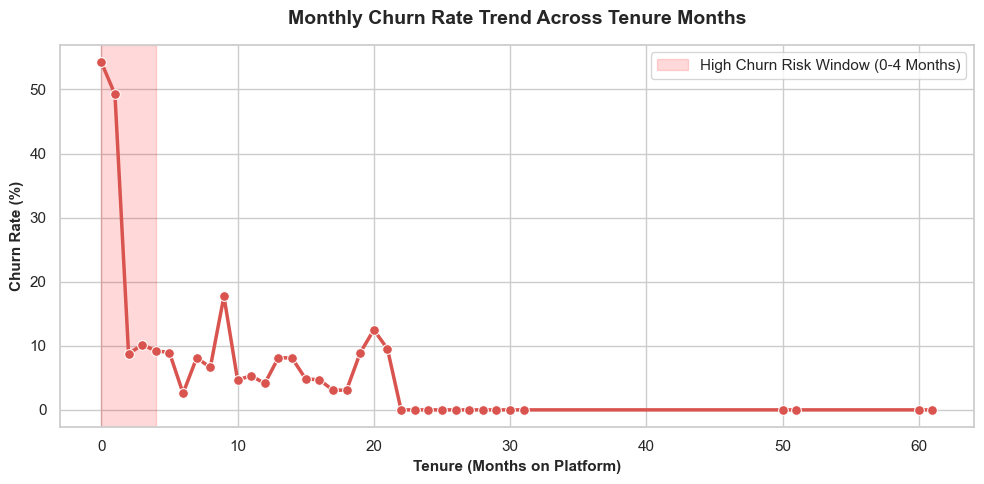

In [66]:
#visualisation using matplotlib
#monthly churn trend
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Monthly Churn Rate Calculation using df_visual
monthly_churn = df_visual.groupby('Tenure')['Churn'].agg(
    Total_Users='count',
    Churned_Users='sum',
    Churn_Rate_Pct=lambda x: (x.mean() * 100)
).reset_index()

# Drop missing tenure values if any
monthly_churn = monthly_churn.dropna(subset=['Tenure'])

# Monthly Trend Line Plot
sns.lineplot(
    data=monthly_churn, 
    x='Tenure', 
    y='Churn_Rate_Pct', 
    marker='o', 
    color='#d9534f', 
    linewidth=2.5,
    markersize=7
)

# Title & Axis Formatting
plt.title('Monthly Churn Rate Trend Across Tenure Months', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenure (Months on Platform)', fontsize=11, fontweight='bold')
plt.ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')

# High Risk Highlight Zone (0 to 4 Months)
plt.axvspan(0, 4, color='red', alpha=0.15, label='High Churn Risk Window (0-4 Months)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

C:\Users\CERSAI\AppData\Local\Temp\ipykernel_17900\244654665.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


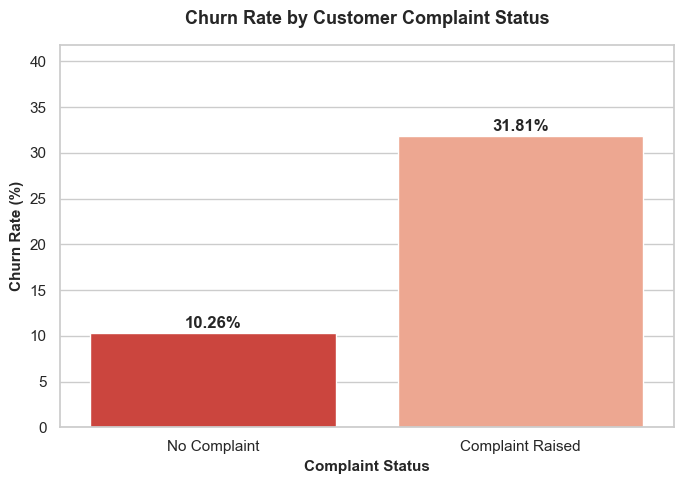

In [71]:
#churn by complaint status
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# Groupby Data
complain_churn = df_visual.groupby('Complain')['Churn'].agg(
    Churn_Rate_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index()
complain_churn['Complain_Label'] = complain_churn['Complain'].map({0: 'No Complaint', 1: 'Complaint Raised'})

# Bar Plot with Red Palette
ax = sns.barplot(
    data=complain_churn, 
    x='Complain_Label', 
    y='Churn_Rate_Pct', 
    palette='Reds_r'
)

# Percentage Labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 7), textcoords='offset points', 
        fontweight='bold'
    )

plt.title('Churn Rate by Customer Complaint Status', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Complaint Status', fontsize=11, fontweight='bold')
plt.ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
plt.ylim(0, max(complain_churn['Churn_Rate_Pct']) + 10)

plt.tight_layout()
plt.show()

C:\Users\CERSAI\AppData\Local\Temp\ipykernel_17900\3799621964.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=tenure_churn, x='Tenure_Bucket', y='Churn_Rate_Pct', palette='Reds_r')


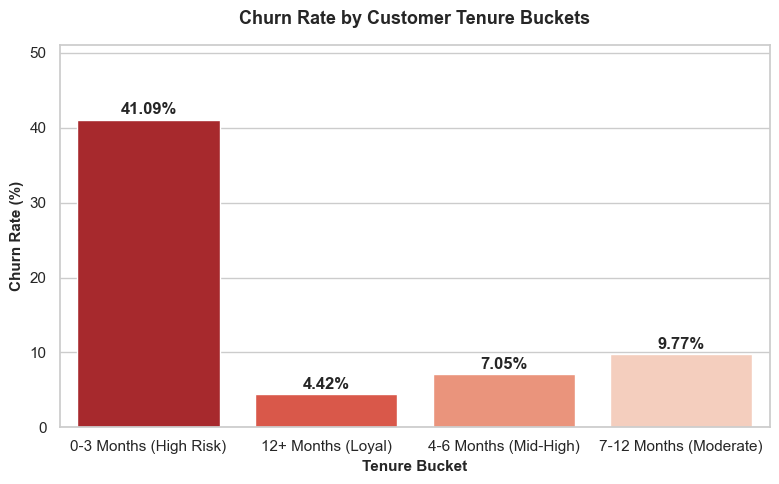

In [70]:
# churn by tenure bucket
plt.figure(figsize=(8, 5))

# Creating Tenure Buckets
def tenure_bucket(tenure):
    if tenure <= 3:
        return '0-3 Months (High Risk)'
    elif tenure <= 6:
        return '4-6 Months (Mid-High)'
    elif tenure <= 12:
        return '7-12 Months (Moderate)'
    else:
        return '12+ Months (Loyal)'

df_visual['Tenure_Bucket'] = df_visual['Tenure'].apply(tenure_bucket)
tenure_churn = df_visual.groupby('Tenure_Bucket')['Churn'].agg(
    Churn_Rate_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index()

ax = sns.barplot(data=tenure_churn, x='Tenure_Bucket', y='Churn_Rate_Pct', palette='Reds_r')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontweight='bold')

plt.title('Churn Rate by Customer Tenure Buckets', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tenure Bucket', fontsize=11, fontweight='bold')
plt.ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
plt.ylim(0, max(tenure_churn['Churn_Rate_Pct']) + 10)
plt.tight_layout()
plt.show()

C:\Users\CERSAI\AppData\Local\Temp\ipykernel_17900\3499169052.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


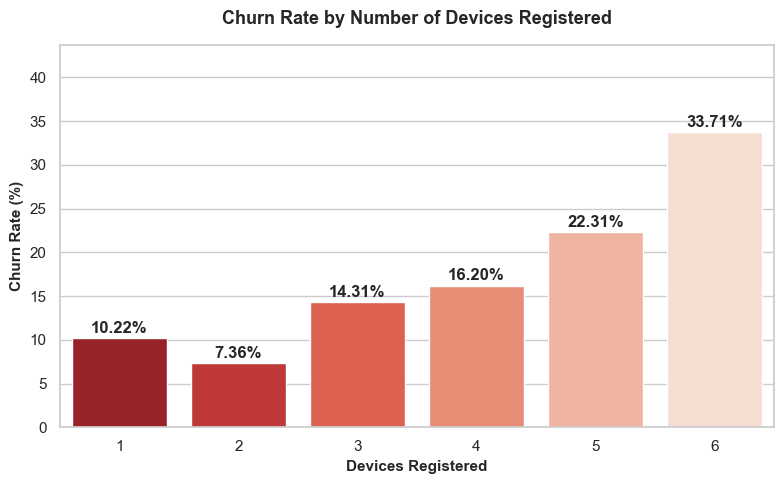

In [72]:
#churn by number of registered devices
plt.figure(figsize=(8, 5))

# Groupby Data
device_churn = df_visual.groupby('NumberOfDeviceRegistered')['Churn'].agg(
    Churn_Rate_Pct=lambda x: round(x.mean() * 100, 2)
).reset_index()

# Bar Plot with Red Palette
ax = sns.barplot(
    data=device_churn, 
    x='NumberOfDeviceRegistered', 
    y='Churn_Rate_Pct', 
    palette='Reds_r'
)

# Percentage Labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 7), textcoords='offset points', 
        fontweight='bold'
    )

plt.title('Churn Rate by Number of Devices Registered', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Devices Registered', fontsize=11, fontweight='bold')
plt.ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
plt.ylim(0, max(device_churn['Churn_Rate_Pct']) + 10)

plt.tight_layout()
plt.show()

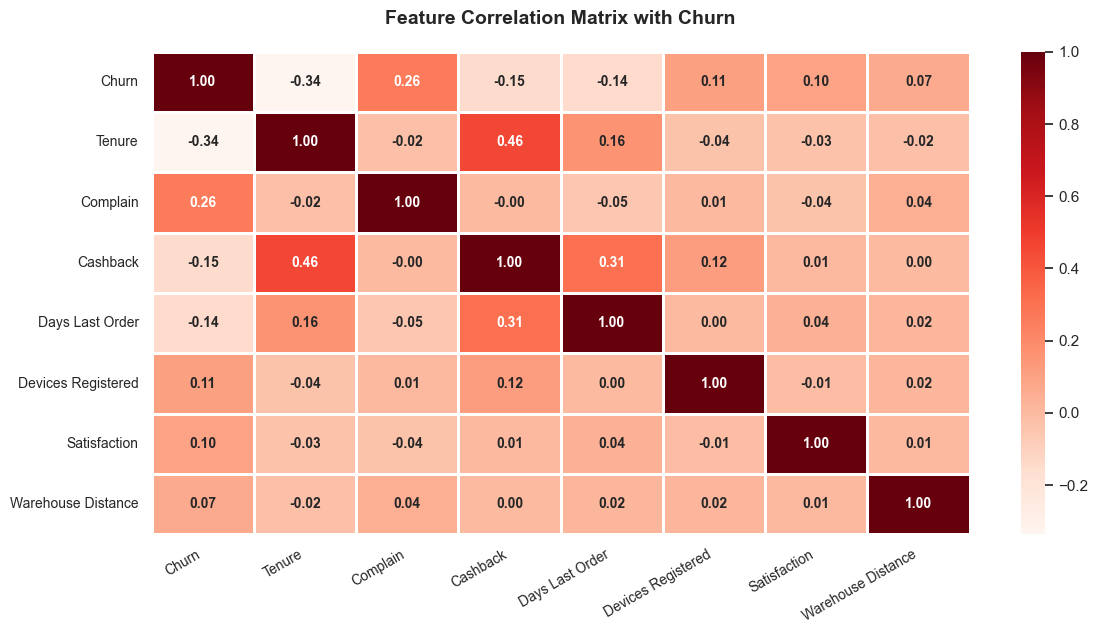

In [75]:
# heatmap for correlation visualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6.5))

# Key numerical columns
corr_columns = [
    'Churn', 'Tenure', 'Complain', 'CashbackAmount', 
    'DaySinceLastOrder', 'NumberOfDeviceRegistered', 
    'SatisfactionScore', 'WarehouseToHome'
]

# Readable labels
clean_labels = [
    'Churn', 'Tenure', 'Complain', 'Cashback', 
    'Days Last Order', 'Devices Registered', 
    'Satisfaction', 'Warehouse Distance'
]

# Correlation matrix calculation
corr_matrix = df_visual[corr_columns].corr()

# Wide Heatmap Plotting
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='Reds',
    linewidths=1,                  
    linecolor='white',
    cbar=True,
    square=False,                 
    xticklabels=clean_labels,
    yticklabels=clean_labels,
    annot_kws={"size": 10, "weight": "bold"}  # Numbers Inside Heatmap -> BOLD
)

# Customization - Axis Labels (Normal) & Title (Bold)
plt.title('Feature Correlation Matrix with Churn', fontsize=14, fontweight='bold', pad=20) # Title -> BOLD
plt.xticks(rotation=30, ha='right', fontsize=10, fontweight='normal')  # X-axis -> NORMAL
plt.yticks(rotation=0, fontsize=10, fontweight='normal')               # Y-axis -> NORMAL

plt.tight_layout()
plt.show()

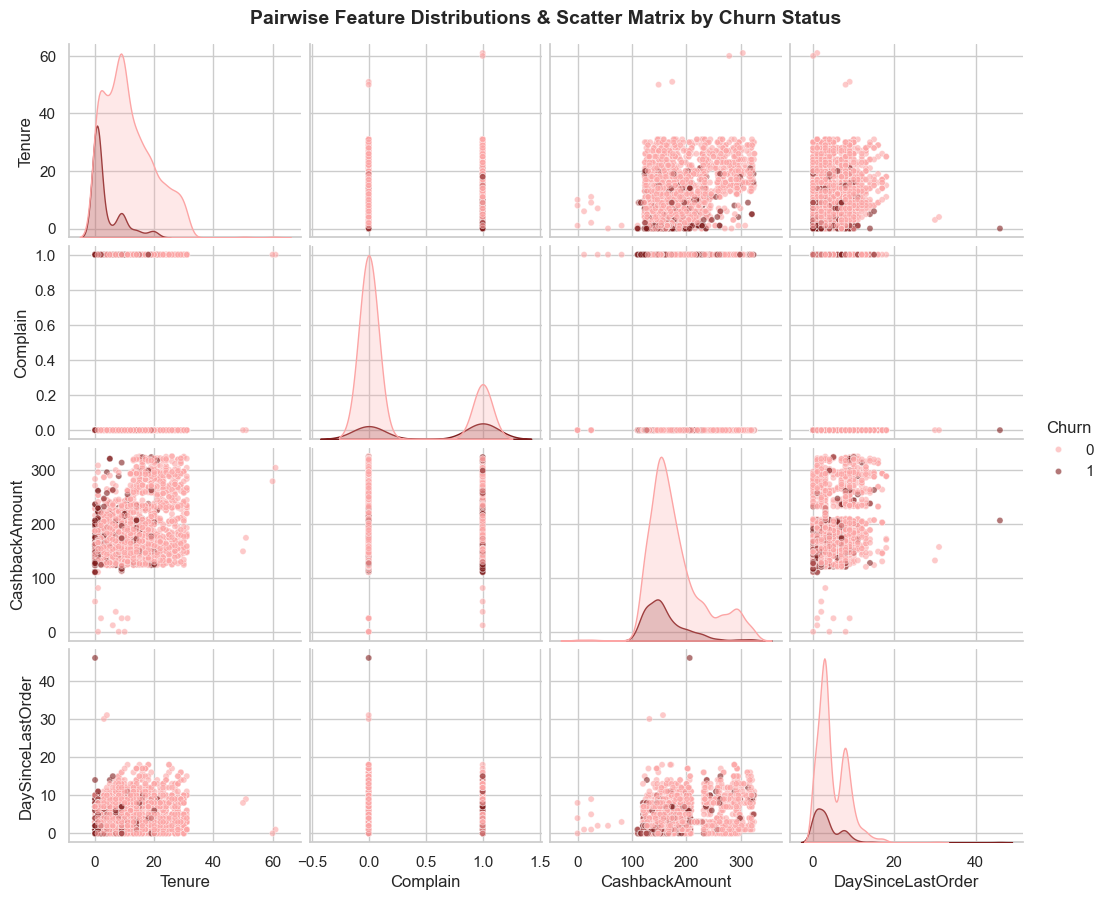

In [77]:
# pair plot - relationship between variables
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall aesthetic style
sns.set_theme(style="whitegrid")

# Select key numerical columns for the pairplot
pairplot_cols = [
    'Churn', 'Tenure', 'Complain', 
    'CashbackAmount', 'DaySinceLastOrder'
]

# Pairplot Generation
g = sns.pairplot(
    data=df_visual[pairplot_cols],
    hue='Churn',                     # Color split based on Churn (0 vs 1)
    palette={0: '#fca5a5', 1: '#7f1d1d'},  # Non-Churn: Muted Blue, Churn: Red
    diag_kind='kde',                 # Smooth density distribution on diagonal
    height=2.2,                      # Balanced size for clean grid
    aspect=1.2,                      # Slightly wider aspect ratio
    plot_kws={'alpha': 0.6, 's': 20} # Transparent scatter points to avoid clutter
)

# Customizing Title & Layout
g.fig.suptitle('Pairwise Feature Distributions & Scatter Matrix by Churn Status', y=1.02, fontsize=14, fontweight='bold')

plt.show()

C:\Users\CERSAI\AppData\Local\Temp\ipykernel_17900\3197585179.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


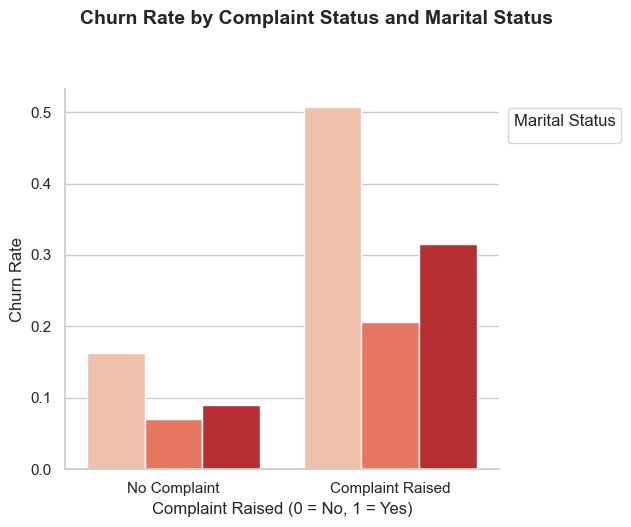

In [83]:
#catplot chart
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

num_categories = df_visual['MaritalStatus'].nunique()
heatmap_reds = sns.color_palette("Reds", n_colors=num_categories)

# legend=False add kiya taaki default legend override kar sakein
g = sns.catplot(
    data=df_visual,
    x='Complain',
    y='Churn',
    hue='MaritalStatus',
    kind='bar',
    palette=heatmap_reds,
    height=5,
    aspect=1.3,
    errorbar=None,
    legend=False  # Custom legend control
)

# Legend ko graph ke outer-right & slightly upper side (bbox_to_anchor) par fit karna
plt.legend(
    title='Marital Status', 
    bbox_to_anchor=(1.02, 0.95),  # Position: (x=1.02 right, y=0.95 height)
    loc='upper left', 
    borderaxespad=0
)

# Title & Axis
g.fig.suptitle('Churn Rate by Complaint Status and Marital Status', y=1.05, fontsize=14, fontweight='bold')
g.set_axis_labels('Complaint Raised (0 = No, 1 = Yes)', 'Churn Rate', fontweight='normal')
g.set_xticklabels(['No Complaint', 'Complaint Raised'], fontweight='normal')

plt.tight_layout()
plt.show()

In [84]:
#pivot table
import pandas as pd

# Creating a summary pivot table for Churn Rate (%)
pivot_summary = pd.pivot_table(
    data=df_visual,
    index='Complain',               # Rows: Complaint Status (0 vs 1)
    columns='MaritalStatus',        # Columns: Single, Married, Divorced
    values='Churn',                 # Value to aggregate
    aggfunc='mean'                  # Mean gives the Churn Rate (percentage)
) * 100                             # Convert ratio to percentage for readability

# Rounding off to 2 decimal places and displaying
pivot_summary = pivot_summary.round(2)
display(pivot_summary)

MaritalStatus,Divorced,Married,Single
Complain,,,
0,9.00,7.10,16.28
1,31.52,20.68,50.71


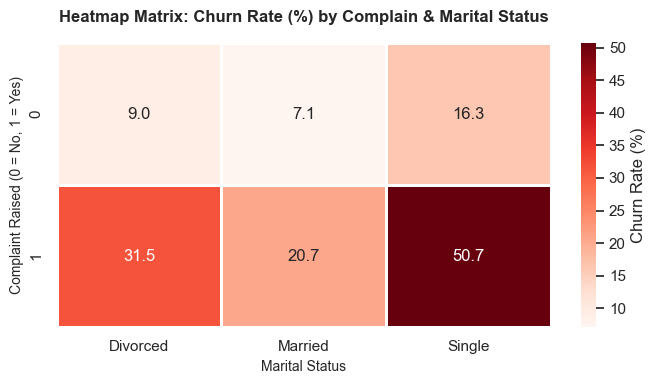

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(7, 4))

# heatmap of pivot table
sns.heatmap(
    pivot_summary, 
    annot=True,            # Show numerical churn % inside cells
    fmt='.1f',             # Round to 1 decimal place with %
    cmap='Reds',           # Heatmap Red Palette Gradient
    linewidths=1,          # Grid line separation between cells
    cbar_kws={'label': 'Churn Rate (%)'}
)

# Title & Axis labels styling
plt.title('Heatmap Matrix: Churn Rate (%) by Complain & Marital Status', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Marital Status', fontsize=10, fontweight='normal')
plt.ylabel('Complaint Raised (0 = No, 1 = Yes)', fontsize=10, fontweight='normal')

plt.tight_layout()
plt.show()